In [1]:
import numpy as np
import matplotlib.pyplot as plt
from numba import cuda, float64, complex128
from numba.cuda import jit as cuda_jit
import math

import few

from few.trajectory.inspiral import EMRIInspiral
from few.trajectory.ode import KerrEccEqFlux
from few.amplitude.ampinterp2d import AmpInterpKerrEccEq
from few.summation.interpolatedmodesum import InterpolatedModeSum


from few.utils.ylm import GetYlms

from few import get_file_manager

from few.waveform import GenerateEMRIWaveform, FastKerrEccentricEquatorialFlux

from few.utils.geodesic import get_fundamental_frequencies

from few.utils.constants import YRSID_SI
from smt.sampling_methods import LHS


import os
import sys

# Changing directory to FEWNEW/work
# to import stuffs
os.chdir('/nfs/home/svu/e1498138/localgit/FEWNEW/work/')
sys.path.insert(0, '/nfs/home/svu/e1498138/localgit/FEWNEW/work/')

import GWfuncs
import loglike_pure   # NON-timemax, NON-phasemax
import parismc
import cupy as cp

# tune few configuration
cfg_set = few.get_config_setter(reset=True)
cfg_set.set_log_level("info")


# GPU configuration
use_gpu = True
force_backend = "cuda12x"
dt = 10     # Time step
T = 3/12     # Total time

print(f"Using dt = {dt} seconds, T = {T} years")

inspiral_kwargs={
        "func": 'KerrEccEqFlux',
        "DENSE_STEPPING": 0,
        "include_minus_m": False,
}

amplitude_kwargs = {
    "force_backend": force_backend
}

Ylm_kwargs = {
    "force_backend": force_backend,
}

sum_kwargs_comb = {
    "force_backend": force_backend,
    "pad_output": True,
}

sum_kwargs_sep = {
    "force_backend": force_backend,
    "pad_output": True,
    "separate_modes": True,
}

print("Creating GenerateEMRIWaveform class...")
waveform_gen_comb = GenerateEMRIWaveform(
    FastKerrEccentricEquatorialFlux,
    frame='detector',
    inspiral_kwargs=inspiral_kwargs,
    amplitude_kwargs=amplitude_kwargs,
    Ylm_kwargs=Ylm_kwargs,
    sum_kwargs=sum_kwargs_comb,
    use_gpu=use_gpu
)

waveform_gen_sep = GenerateEMRIWaveform(
    FastKerrEccentricEquatorialFlux,
    frame='detector',
    inspiral_kwargs=inspiral_kwargs,
    amplitude_kwargs=amplitude_kwargs,
    Ylm_kwargs=Ylm_kwargs,
    sum_kwargs=sum_kwargs_sep,
    use_gpu=use_gpu
)

print('Done initializing waveform generator.')

print("Creating GravWaveAnalysis class...")
gwf = GWfuncs.GravWaveAnalysis(T, dt)

print("Initializing loglike class...")


# Source parameters
m1 = 1e6
m2 = 1e1
a = 0.7
p0 = 9
e0 = 0.4
xI0 = 1.0
dist = 1.8  # Gpc
qS = np.pi
phiS = 0.
qK =  0.
phiK = 0.
Phi_phi0 = 0.4
Phi_theta0 = 0.0
Phi_r0 = 0.5

params_star = (m1, m2, a, p0, e0, xI0, dist, qS, phiS, qK, phiK, Phi_phi0, Phi_theta0, Phi_r0)
param_true = [np.log10(m1), np.log10(m2), a, p0, e0]

n_vals = np.arange(-1,6)
ell = 2

loglike_obj = loglike_pure.LogLikePure(
    params_star,
    waveform_gen_comb,
    gwf,
    verbose=False,
    waveform_gen_sep=waveform_gen_sep,
    ell=ell,
    n_vals=n_vals,
    M_mode=None
)

print('Done initializing loglike class.')

data     = loglike_obj.signal
data_snr = float(gwf.rhostat(data))
print('SNR:', data_snr)


Using dt = 10 seconds, T = 0.25 years
Creating GenerateEMRIWaveform class...
Done initializing waveform generator.
Creating GravWaveAnalysis class...
Initializing loglike class...
Done initializing loglike class.
SNR: 5.942134448355127


In [2]:
pwd

'/nfs/home/svu/e1498138/localgit/FEWNEW/work'

In [3]:
# prior bounds
_p2_lo = np.array([5.6, 0.8, 0.3, 8.0, 0.2])
_p2_hi = np.array([6.4, 1.3, 0.99, 11.0, 0.5])

def log_density(params):      
    raise RuntimeError("stub")

def prior_transform(u):
    return _p2_lo + (_p2_hi - _p2_lo) * u
sampler_2 = parismc.Sampler.load_state(
    './search/intrinsic_ffunc_3mth_snr32_paris2/sampler_state.pkl'
)

# S_ANNEAL = 30

# Max logden point from paris2_1 (in physical space)
all_pts_u  = sampler_2.searched_points_list[0]
all_logden = sampler_2.searched_log_densities_list[0]
maxld_idx  = np.argmax(all_logden)
mu_center  = prior_transform(all_pts_u[maxld_idx].reshape(1, -1))[0]
print(f'stage 2 maxld: {all_logden[maxld_idx]:.4f}')
print(f'stage 2 maxld point:    {mu_center}')

# Posterior covariance from paris2_1: importance-weight resample then np.cov
samples_p2, weights_p2 = sampler_2.get_samples_with_weights(flatten=True)
weights_p2 = weights_p2 / weights_p2.sum()
rng_rs = np.random.default_rng(0)
idx_rs = rng_rs.choice(len(samples_p2), size=50_000, replace=True, p=weights_p2)
cov_posterior =  np.cov(samples_p2[idx_rs].T)  # physical-space posterior covariance
print('stage 2 posterior 1-sigma (diag, using S):', np.sqrt(np.diag(cov_posterior)))



stage 2 maxld: 590.5817
stage 2 maxld point:    [6.01487994 1.00500901 0.73205648 8.81696887 0.39543265]
stage 2 posterior 1-sigma (diag, using S): [0.00929708 0.00521965 0.01918811 0.11027935 0.00390186]


In [4]:
del sampler_2, samples_p2, weights_p2, idx_rs  # free memory


In [5]:

# ─────────────────────────────────────────────
# Ellipsoidal prior definition
# ─────────────────────────────────────────────

N_SIGMA_PRIOR = 3.0   # ellipse radius in units of posterior sigma

# Tight bounding box: mu_center ± N_SIGMA_PRIOR * sigma, clipped to original prior
sigma_diag  = np.sqrt(np.diag(cov_posterior))
ellipse_lo  = np.clip(mu_center - N_SIGMA_PRIOR * sigma_diag, _p2_lo, _p2_hi)
ellipse_hi  = np.clip(mu_center + N_SIGMA_PRIOR * sigma_diag, _p2_lo, _p2_hi)
cov_inv     = np.linalg.inv(cov_posterior)

# Sanity check: is the true point inside the ellipse?
param_true_phys = np.array([np.log10(m1), np.log10(m2), a, p0, e0])
diff_true = param_true_phys - mu_center
maha_true = np.sqrt(diff_true @ cov_inv @ diff_true)
print(f'Mahalanobis distance (maxld_pt -> true point): {maha_true:.3f}σ')
if maha_true > N_SIGMA_PRIOR:
    print(f'WARNING: true point is OUTSIDE the {N_SIGMA_PRIOR:.0f}σ ellipse!')
else:
    print(f'OK: true point is inside the {N_SIGMA_PRIOR:.0f}σ ellipse.')

print(f'Ellipse prior ({N_SIGMA_PRIOR:.0f}σ) bounds:')
param_names = ['logm1', 'logm2', 'a', 'p0', 'e0']
for i, name in enumerate(param_names):
    print(f'  {name}: [{ellipse_lo[i]:.5f}, {ellipse_hi[i]:.5f}]  (mu={mu_center[i]:.5f})')

# Redefine prior_transform and its inverse for the tight box
def prior_transform(u):
    return ellipse_lo + (ellipse_hi - ellipse_lo) * u

def inverse_prior_transform(params):
    params = np.asarray(params)
    return (params - ellipse_lo) / (ellipse_hi - ellipse_lo)

# ─────────────────────────────────────────────
# log_density: NON-phasemax  + ellipse guard
# ─────────────────────────────────────────────

def log_density(params):
    global _EARLY_STOP_HIT
    params = np.asarray(params)
    n_samples = params.shape[0]
    log_likes = np.zeros(n_samples)

    for i in range(n_samples):
        if _EARLY_STOP_HIT:
            log_likes[i] = -np.inf
            continue

        logm1, logm2, a_i, p0_i, e0_i = params[i]

        # Ellipse guard: reject points outside N_SIGMA_PRIOR ellipse
        diff  = params[i] - mu_center
        maha2 = diff @ cov_inv @ diff
        if maha2 > N_SIGMA_PRIOR ** 2:
            log_likes[i] = -np.inf
            continue

        try:
            loglike = loglike_obj(np.array([
                10**logm1, 10**logm2, a_i, p0_i, e0_i,
                xI0, dist, qS, phiS, qK, phiK, Phi_phi0, Phi_theta0, Phi_r0
            ])) 
        except Exception:
            loglike = -np.inf

        if np.isfinite(loglike) and loglike >= _TARGET_LOGLIKE:
            _EARLY_STOP_HIT = True
            print(f'[EARLY-STOP] loglike {loglike:.6f} >= target {_TARGET_LOGLIKE:.6f}; future calls => -inf', flush=True)

        log_likes[i] = loglike

    return log_likes

Mahalanobis distance (maxld_pt -> true point): 2.689σ
OK: true point is inside the 3σ ellipse.
Ellipse prior (3σ) bounds:
  logm1: [5.98699, 6.04277]  (mu=6.01488)
  logm2: [0.98935, 1.02067]  (mu=1.00501)
  a: [0.67449, 0.78962]  (mu=0.73206)
  p0: [8.48613, 9.14781]  (mu=8.81697)
  e0: [0.38373, 0.40714]  (mu=0.39543)


In [6]:
sampler = parismc.Sampler.load_state('./search/intrinsic_ffunc_3mth_snr32_paris3_5/sampler_state.pkl')                                                                      
samples, weights = sampler.get_samples_with_weights(flatten=True)

In [7]:
proc_pt = sampler.searched_points_list
proc_pt

[array([[0.5       , 0.5       , 0.5       , 0.5       , 0.5       ],
        [0.60250462, 0.74042599, 0.57431428, 0.42665773, 0.28735059],
        [0.8075704 , 0.61232766, 0.83152845, 0.16876784, 0.32905911],
        ...,
        [0.65626311, 0.60489229, 0.65879921, 0.34231153, 0.38780748],
        [0.56961631, 0.81796441, 0.51885714, 0.48200266, 0.23856169],
        [0.57535972, 0.25422768, 0.63540422, 0.36420867, 0.66489737]],
       shape=(200000, 5))]

In [8]:
logden_list = sampler.searched_log_densities_list
logden_list

[array([ 1.49499066,  0.00166521, -0.00216511, ...,        -inf,
               -inf,        -inf], shape=(200000,))]

In [ ]:
maxld_pt1 = prior_transform(proc_pt[0][np.argmax(logden_list)].reshape(1, -1))
maxld_pt1

array([[6.01112701, 1.00437234, 0.72360392, 8.86546466, 0.39622541]])

In [10]:
_EARLY_STOP_HIT=False
_TARGET_LOGLIKE = 5.90716261

log_density(maxld_pt1)

[EARLY-STOP] loglike 5.907552 >= target 5.907163; future calls => -inf


array([5.90755207])

In [11]:
_EARLY_STOP_HIT=False


In [12]:
log_density([param_true])

[EARLY-STOP] loglike 5.907163 >= target 5.907163; future calls => -inf


array([5.90716261])

In [13]:
_EARLY_STOP_HIT=False


In [ ]:
logm1_pt, logm2_pt, a_pt, p0_pt, e0_pt = maxld_pt1[0]

h_pt1 = waveform_gen_comb(
    10**logm1_pt, 10**logm2_pt, a_pt, p0_pt, e0_pt,
    xI0, dist, qS, phiS, qK, phiK, Phi_phi0, Phi_theta0, Phi_r0,
    dt=dt, T=T
)

In [15]:
gwf.rhostat(h_pt1)

array(5.98645821)

In [16]:
gwf.Xstat(data, data)

array(5.94213445)

In [17]:
gwf.Xstat_timemax(data, h_pt1), gwf.Xstat(data, h_pt1)

(array(5.93836056), array(5.93663565))

In [18]:
param_ranges = [(5.6,6.4),
                (0.8,1.3),
                (0.3,0.99),
                (8.0,11.0),
                (0.2,0.5)
                ]
param_ranges

[(5.6, 6.4), (0.8, 1.3), (0.3, 0.99), (8.0, 11.0), (0.2, 0.5)]

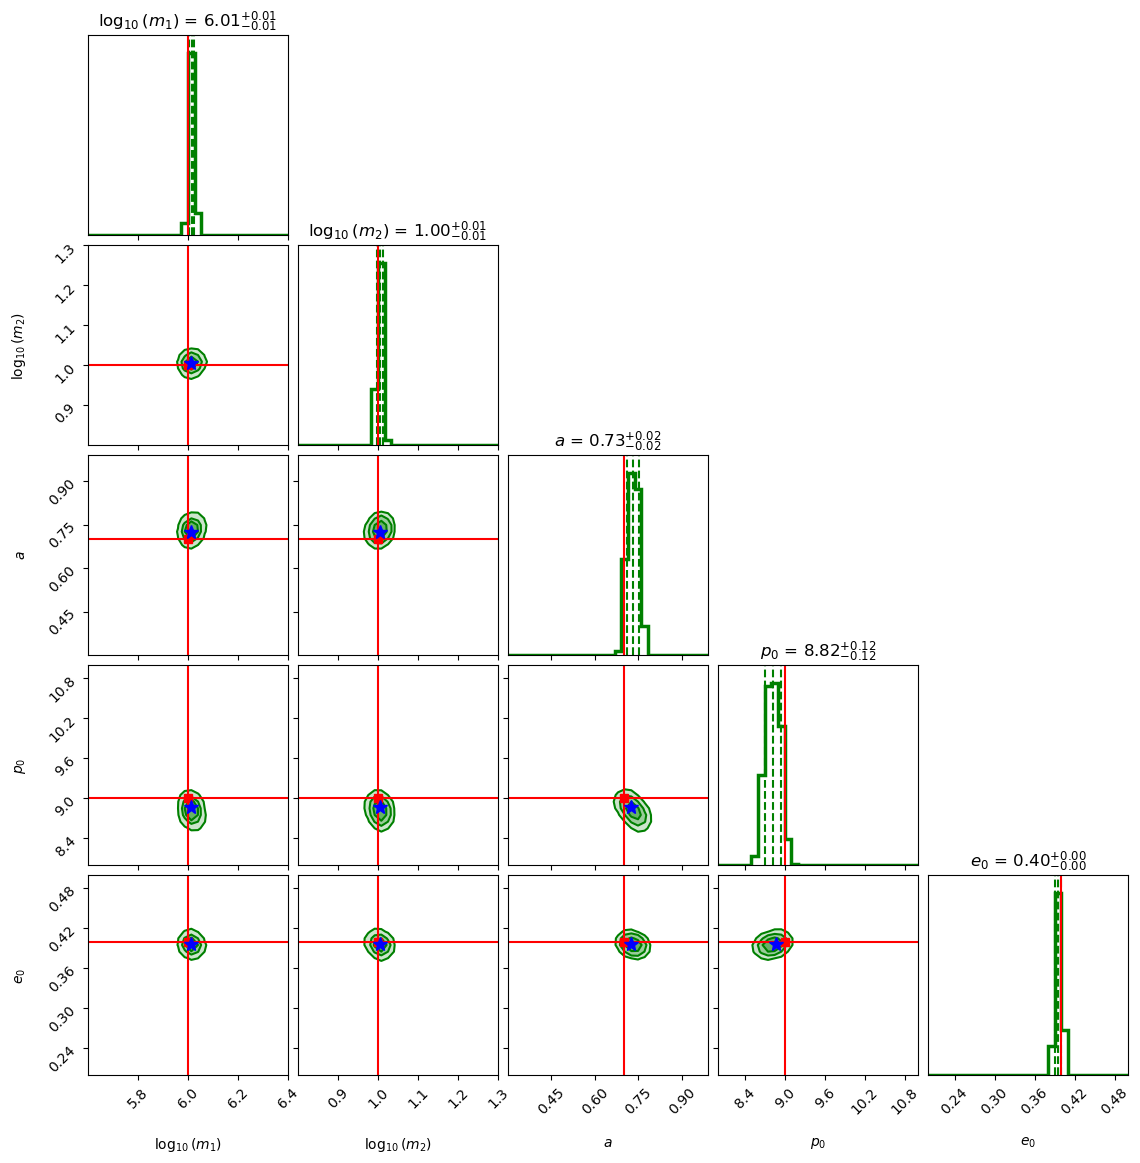

In [19]:
import corner
labels = [r'$\log_{10}(m_1)$', r'$\log_{10}(m_2)$', r'$a$', r'$p_0$', r'$e_0$']
fig = corner.corner(
    samples,
    weights=weights,
    labels=labels,
    truths=param_true,
    truth_color='red',
    color='green',
    show_titles=True,
    label_kwargs={"fontsize": 10},
    title_kwargs={"fontsize": 12},
    quantiles=[0.16, 0.5, 0.84],
    smooth=True,
    bins=30,
    plot_datapoints=False,
    hist_kwargs={"density": True, 'linewidth': 2.5},
    linewidth=2.5,
    fill_contours=True,
    range = param_ranges
)

corner.overplot_points(fig, maxld_pt1.reshape(1, -1), 
                       color='blue', marker='*', ms=10, 
                       reverse=False)




#  connection

In [ ]:
def log_density(params):
    params = np.asarray(params)
    n_samples = params.shape[0]
    log_likes = np.zeros(n_samples)

    for i in range(n_samples):

        logm1, logm2, a_i, p0_i, e0_i = params[i]

        try:
            loglike = loglike_obj(np.array([
                10**logm1, 10**logm2, a_i, p0_i, e0_i,
                xI0, dist, qS, phiS, qK, phiK, Phi_phi0, Phi_theta0, Phi_r0
            ])) 
        except Exception:
            loglike = -np.inf

        log_likes[i] = loglike

    return log_likes

In [21]:
proc1_maxld_pt = maxld_pt1.copy()
proc1_maxld_pt

array([[6.01112701, 1.00437234, 0.72360392, 8.86546466, 0.39622541]])

In [ ]:
# connect two highest logden pts

proc1_maxld_pt_1d = proc1_maxld_pt[0] 
true_pt = np.array(param_true)

# NOTE: connecting only till the true/target pt 
n_points = 50
t_values = np.linspace(0, 1, n_points)  # extend beyond each endpoint
line_points_proc1 = proc1_maxld_pt_1d[:, np.newaxis] + t_values * (true_pt - proc1_maxld_pt_1d)[:, np.newaxis]


In [23]:
logden_theory_proc1 = []
logden_theory_proc1.append(log_density(np.array(line_points_proc1).T))


In [ ]:
logden_theory_proc1 = np.array(logden_theory_proc1).flatten()


In [25]:
logden_theory_proc1

array([ 5.90755207,  5.68611794,  4.92951379,  3.62247483,  2.17625759,
        1.07069122,  0.43497489,  0.13424121,  0.00775021, -0.04221231,
       -0.06130735, -0.06838561, -0.07076194, -0.07114279, -0.07046734,
       -0.06904441, -0.06700656, -0.06448296, -0.06164813, -0.05871414,
       -0.05590848, -0.05344412, -0.05150183, -0.05021881, -0.04968311,
       -0.04993334, -0.05095852, -0.05269957, -0.05504719, -0.05784732,
       -0.06090533, -0.06400253, -0.06691751, -0.06945658, -0.07147658,
       -0.07288533, -0.07357927, -0.0732433 , -0.07083494, -0.06329917,
       -0.04237062,  0.01312184,  0.15365968,  0.48395666,  1.16624883,
        2.31417964,  3.75800331,  5.01204948,  5.71297786,  5.90716261])

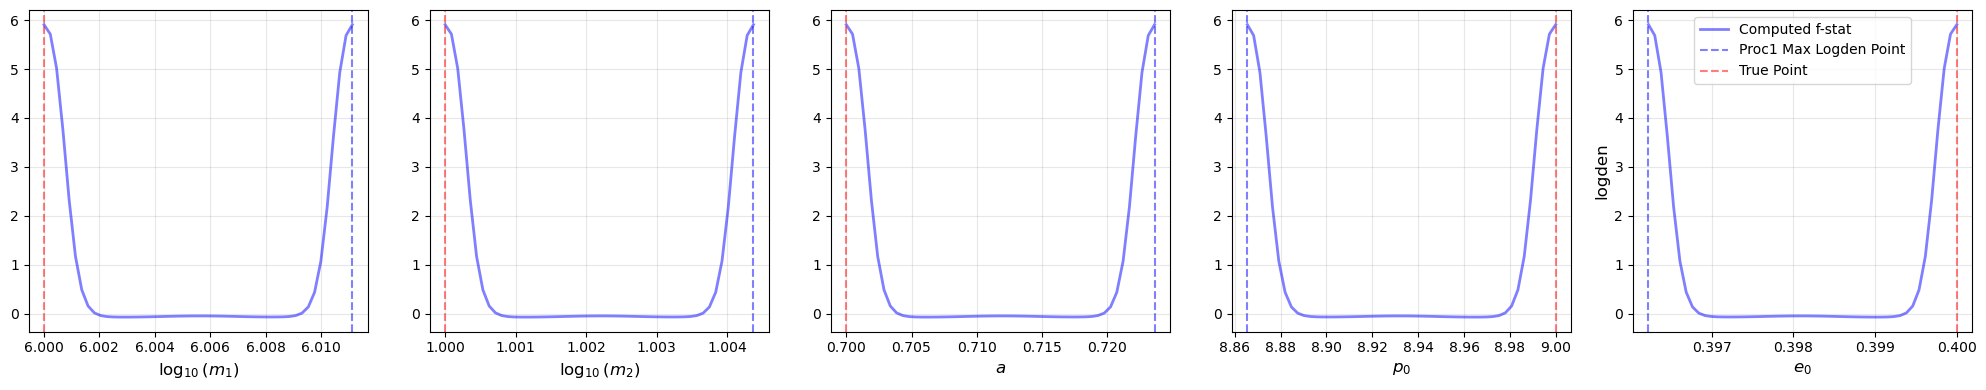

In [26]:
fig_1d, axs_1d = plt.subplots(1, 5, figsize=(20, 4))
labels = [r'$\log_{10}(m_1)$', r'$\log_{10}(m_2)$', r'$a$', r'$p_0$', r'$e_0$']
plt.ylabel('logden', fontsize=12)
for dim in range(5):
    ax = axs_1d[dim]

    # Plot theoretical log-density
    ax.plot(line_points_proc1[dim], logden_theory_proc1, '-', 
            color='blue', alpha=0.5, linewidth=2, label='Computed f-stat')


    # Mark the max likelihood points
    ax.axvline(proc1_maxld_pt_1d[dim], color='blue', linestyle='--', 
               alpha=0.5, label=f'Proc1 Max Logden Point')
    ax.axvline(param_true[dim], color='red', linestyle='--', 
               alpha=0.5, label='True Point')
    
    ax.set_xlabel(labels[dim], fontsize=12)
    # ax.set_ylabel('logden', fontsize=12)
    ax.grid(True, alpha=0.3)

plt.legend()
plt.tight_layout()


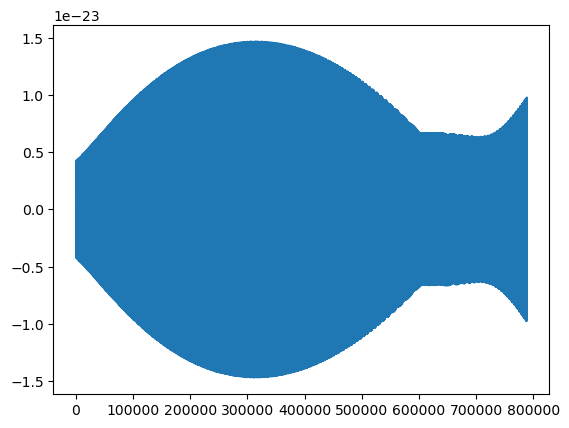

In [27]:
plt.plot(h_pt1.get().real-data.get().real)
# plt.plot(h_pt1.get().imag-data.get().imag)

plt.show()

In [28]:
templates_proc1 = []
for point in line_points_proc1.T:
    logm1, logm2, a, p0, e0 = point
    m1 = 10**logm1
    m2 = 10**logm2
    template = waveform_gen_comb(m1, m2, a, p0, e0, xI0, dist, 
                                 qS, phiS, qK, phiK, 
                                 Phi_phi0, Phi_theta0, Phi_r0,
                                 dt=dt, T=T)
    templates_proc1.append(template)

In [29]:
import GWfuncs_pure
gwf_p = GWfuncs_pure.GravWaveAnalysis(T,dt)

In [30]:
X_proc1_nont = []
for template in templates_proc1:
    X = gwf_p.Xstat(data, template)
    X_proc1_nont.append(X.get())

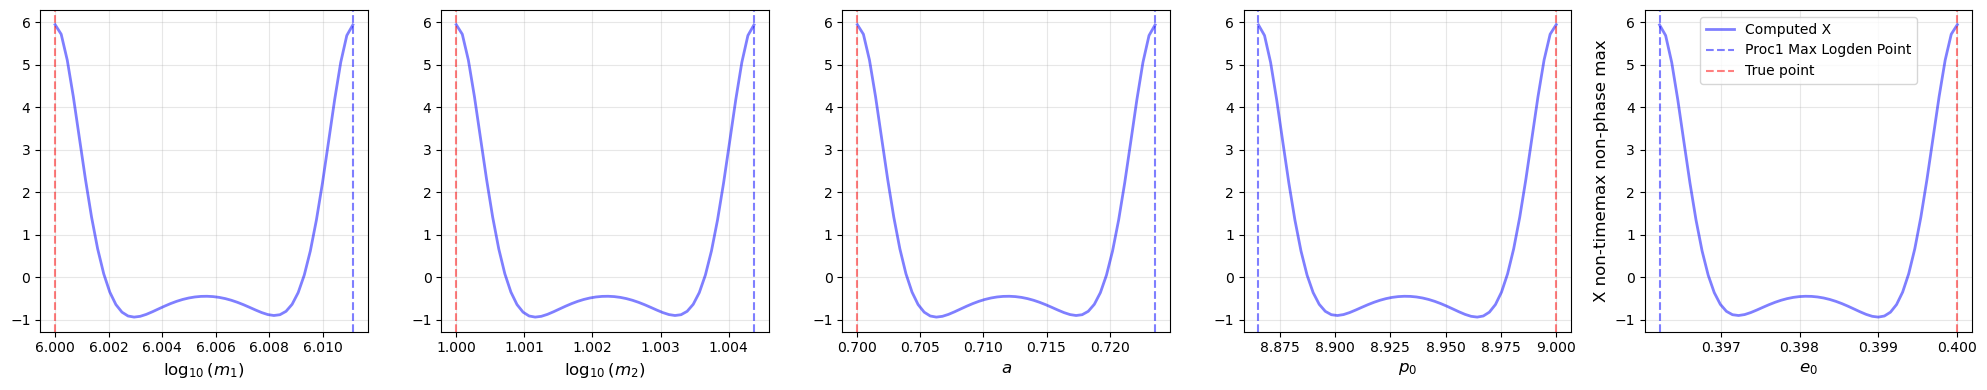

In [31]:
fig_1d, axs_1d = plt.subplots(1, 5, figsize=(20, 4))
plt.ylabel('X non-timemax non-phase max', fontsize=12)

for dim in range(5):
    ax = axs_1d[dim]

    # Plot theoretical log-density
    ax.plot(line_points_proc1[dim], X_proc1_nont, '-', 
            color='blue', alpha=0.5, linewidth=2, label='Computed X')

    # Mark the max likelihood points
    ax.axvline(proc1_maxld_pt_1d[dim], color='blue', linestyle='--', 
               alpha=0.5, label=f'Proc1 Max Logden Point')
    ax.axvline(param_true[dim], color='red', linestyle='--', 
               alpha=0.5, label='True point')
    
    ax.set_xlabel(labels[dim], fontsize=12)
    # ax.set_ylabel('opt SNR (X)', fontsize=12)
    ax.grid(True, alpha=0.3)

plt.legend()
plt.tight_layout()


In [88]:
gwf_6mth = GWfuncs_pure.GravWaveAnalysis(6/12,dt)

In [89]:
gwf_6mth.fft_freqs_rfft

array([0.00000000e+00, 6.33750510e-08, 1.26750102e-07, ...,
       4.99998732e-02, 4.99999366e-02, 5.00000000e-02], shape=(788955,))

In [90]:
templates_proc1_6mth = []
for point in line_points_proc1.T:
    logm1, logm2, a, p0, e0 = point
    m1 = 10**logm1
    m2 = 10**logm2
    template = waveform_gen_comb(m1, m2, a, p0, e0, xI0, dist, 
                                 qS, phiS, qK, phiK, 
                                 Phi_phi0, Phi_theta0, Phi_r0,
                                 dt=dt, T=6/12)
    templates_proc1_6mth.append(template)

In [92]:
m1,m2,a,p0,e0

(np.float64(1000000.0),
 np.float64(10.0),
 np.float64(0.7),
 np.float64(9.0),
 np.float64(0.4))

In [93]:
data_6mth = waveform_gen_comb(m1, m2, a, p0, e0, xI0, dist, 
                                 qS, phiS, qK, phiK, 
                                 Phi_phi0, Phi_theta0, Phi_r0,
                                 dt=dt, T=6/12)

In [94]:
X_proc1_6mth = []
for template in templates_proc1_6mth:
    X = gwf_6mth.Xstat(data_6mth, template)
    X_proc1_6mth.append(X.get())

In [95]:
X_proc1_6mth

[array(7.21589449),
 array(7.97623783),
 array(6.54188331),
 array(3.3621743),
 array(-0.14392481),
 array(-2.53523592),
 array(-3.20541834),
 array(-2.4922677),
 array(-1.17848615),
 array(0.05269342),
 array(0.85867264),
 array(1.19864968),
 array(1.18968424),
 array(0.98403208),
 array(0.70546916),
 array(0.43194982),
 array(0.20171707),
 array(0.02642158),
 array(-0.09701321),
 array(-0.17791559),
 array(-0.22703048),
 array(-0.2540035),
 array(-0.26648644),
 array(-0.27000733),
 array(-0.26817037),
 array(-0.26296069),
 array(-0.25500691),
 array(-0.24374292),
 array(-0.22750237),
 array(-0.20358009),
 array(-0.16827032),
 array(-0.11715495),
 array(-0.04561592),
 array(0.04995325),
 array(0.17018256),
 array(0.30960895),
 array(0.45256197),
 array(0.56870553),
 array(0.61029084),
 array(0.51515914),
 array(0.22160777),
 array(-0.29748102),
 array(-0.9785101),
 array(-1.60157967),
 array(-1.75923219),
 array(-0.94037667),
 array(1.19258354),
 array(4.37540175),
 array(7.46629169),

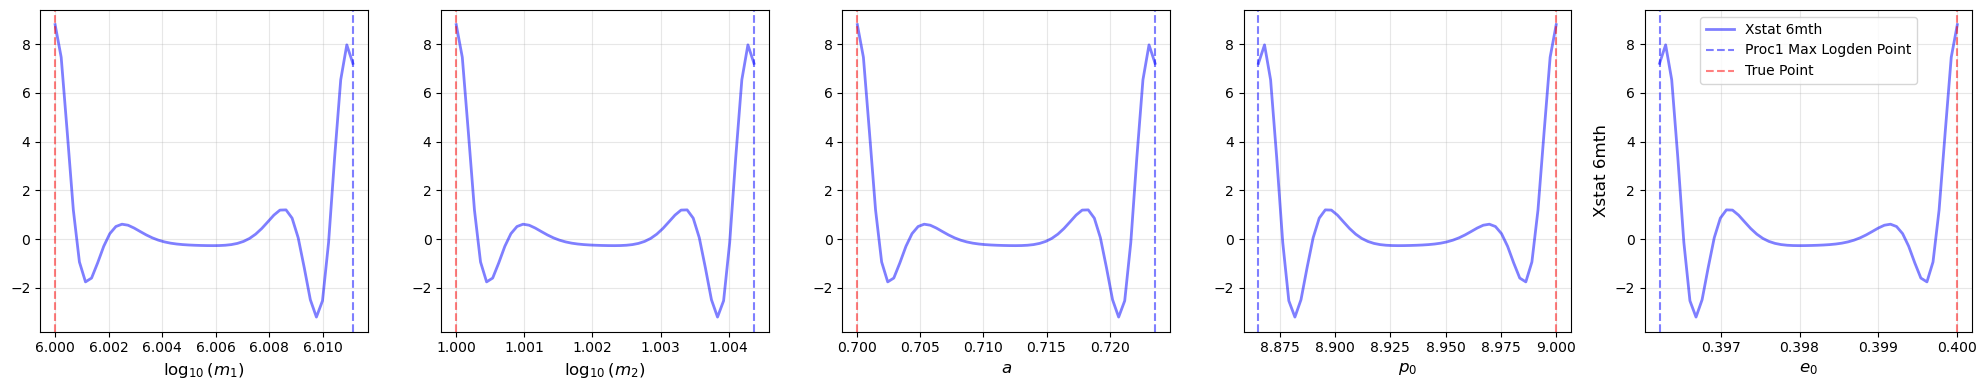

In [96]:
fig_1d, axs_1d = plt.subplots(1, 5, figsize=(20, 4))
labels = [r'$\log_{10}(m_1)$', r'$\log_{10}(m_2)$', r'$a$', r'$p_0$', r'$e_0$']
plt.ylabel('Xstat 6mth', fontsize=12)
for dim in range(5):
    ax = axs_1d[dim]

    # Plot theoretical log-density
    ax.plot(line_points_proc1[dim], X_proc1_6mth, '-', 
            color='blue', alpha=0.5, linewidth=2, label='Xstat 6mth')


    # Mark the max likelihood points
    ax.axvline(proc1_maxld_pt_1d[dim], color='blue', linestyle='--', 
               alpha=0.5, label=f'Proc1 Max Logden Point')
    ax.axvline(param_true[dim], color='red', linestyle='--', 
               alpha=0.5, label='True Point')
    
    ax.set_xlabel(labels[dim], fontsize=12)
    # ax.set_ylabel('logden', fontsize=12)
    ax.grid(True, alpha=0.3)

plt.legend()
plt.tight_layout()


In [98]:
gwf_1yr = GWfuncs_pure.GravWaveAnalysis(12/12,dt)

In [97]:
data_1yr = waveform_gen_comb(m1, m2, a, p0, e0, xI0, dist, 
                                 qS, phiS, qK, phiK, 
                                 Phi_phi0, Phi_theta0, Phi_r0,
                                 dt=dt, T=12/12)

In [99]:
templates_proc1_1yr = []
for point in line_points_proc1.T:
    logm1, logm2, a, p0, e0 = point
    m1 = 10**logm1
    m2 = 10**logm2
    template = waveform_gen_comb(m1, m2, a, p0, e0, xI0, dist, 
                                 qS, phiS, qK, phiK, 
                                 Phi_phi0, Phi_theta0, Phi_r0,
                                 dt=dt, T=12/12)
    templates_proc1_1yr.append(template)

In [100]:
X_proc1_1yr = []
for template in templates_proc1_1yr:
    X = gwf_1yr.Xstat(data_1yr, template)
    X_proc1_1yr.append(X.get())

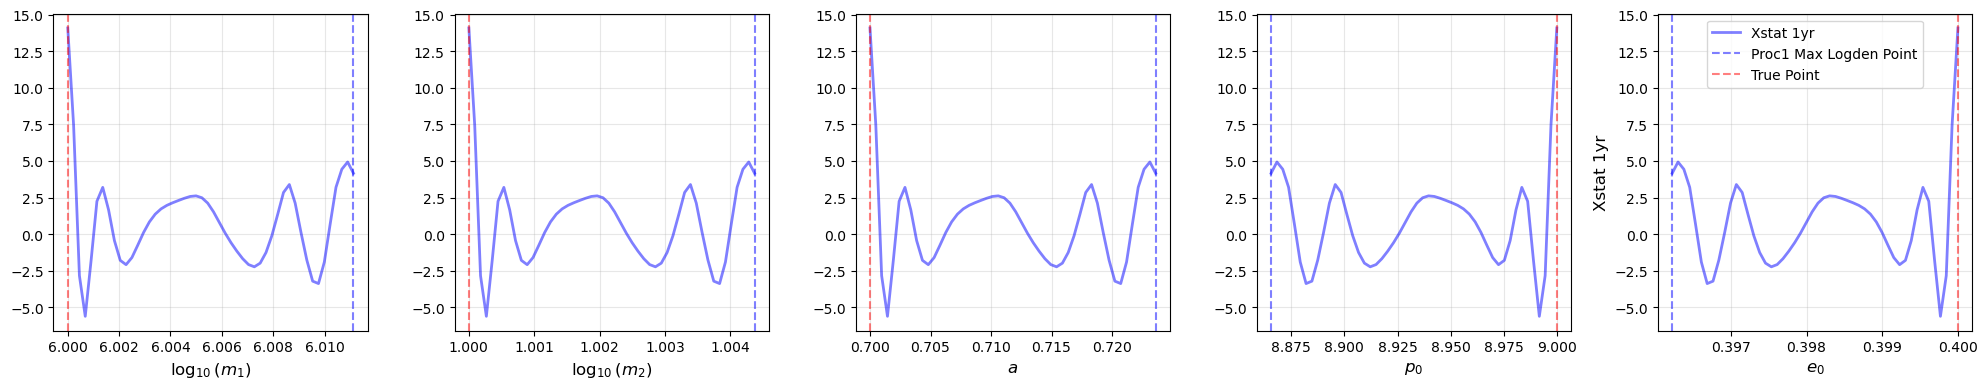

In [101]:
fig_1d, axs_1d = plt.subplots(1, 5, figsize=(20, 4))
labels = [r'$\log_{10}(m_1)$', r'$\log_{10}(m_2)$', r'$a$', r'$p_0$', r'$e_0$']
plt.ylabel('Xstat 1yr', fontsize=12)
for dim in range(5):
    ax = axs_1d[dim]

    # Plot theoretical log-density
    ax.plot(line_points_proc1[dim], X_proc1_1yr, '-', 
            color='blue', alpha=0.5, linewidth=2, label='Xstat 1yr')


    # Mark the max likelihood points
    ax.axvline(proc1_maxld_pt_1d[dim], color='blue', linestyle='--', 
               alpha=0.5, label=f'Proc1 Max Logden Point')
    ax.axvline(param_true[dim], color='red', linestyle='--', 
               alpha=0.5, label='True Point')
    
    ax.set_xlabel(labels[dim], fontsize=12)
    # ax.set_ylabel('logden', fontsize=12)
    ax.grid(True, alpha=0.3)

plt.legend()
plt.tight_layout()


In [33]:
groups = [
    [(2,-2,-1),(2,-1,-1),  (2,0,-1), (2,1,-1), (2,2,-1)],#0
    [(2,-2,0),(2,-1,0),  (2,0,0), (2,1,0), (2,2,0)],#1
    [(2,-2,1),(2,-1,1),  (2,0,1), (2,1,1), (2,2,1)],#2
    [(2,-2,2),(2,-1,2),  (2,0,2), (2,1,2), (2,2,2)],#3
    [(2,-2,3),(2,-1,3),  (2,0,3), (2,1,3), (2,2,3)],#4
    [(2,-2,4),(2,-1,4),  (2,0,4), (2,1,4), (2,2,4)],#5
    [(2,-2,5),(2,-1,5),  (2,0,5), (2,1,5), (2,2,5)],#6
]

In [34]:
amp = getattr(waveform_gen_sep.waveform_generator, 'amplitude_generator', None)    
mode_forms = []

for point in line_points_proc1.T:
    logm1, logm2, a, p0, e0 = point
    m1 = 10**logm1
    m2 = 10**logm2
    
    # Generate waveforms for each GROUP 
    waveforms_per_group = []
    for group in groups:
        mode_form= waveform_gen_comb(m1, m2, a, p0, e0, xI0, dist,
                                    qS, phiS, qK, phiK, 
                                    Phi_phi0, Phi_theta0, Phi_r0,
                                    dt=dt, T=T,
                                    mode_selection=group,  # Pass group list
                                    include_minus_mkn=False)

        # mode_form_group = waveform_gen_sep(m1, m2, a, p0, e0, xI0, dist,
        #                                   qS, phiS, qK, phiK, 
        #                                   Phi_phi0, Phi_theta0, Phi_r0,
        #                                   dt=dt, T=T,
        #                                   mode_selection=group,  # Pass group list
        #                                   include_minus_mkn=False)
        # # Sum all modes within this group
        # mode_form_summed = np.sum(mode_form_group, axis=1)
        waveforms_per_group.append(mode_form)
    
    # Stack into array: shape (N_samples, N_groups)
    mode_form = np.stack(waveforms_per_group, axis=1)
    mode_forms.append(mode_form)


In [35]:
rhostats_proc1 = []
for hm_arr in mode_forms:
    rhostats_proc1.append(gwf_p.rhostat_modes(hm_arr.T))

In [36]:
rhostats_proc1[0] #sec

array([0.19603076, 0.33790044, 1.54655541, 3.70011075, 3.19758276,
       1.98739979, 1.10101111])

In [37]:
rhostats_proc1[-1] #true

array([0.19248603, 0.32069291, 1.50244027, 3.64528079, 3.19028491,
       2.00740266, 1.12572087])

In [38]:
Xm_proc1 = []
for idx, hm_arr in enumerate(mode_forms):
    X_mode = gwf_p.Xmstat(data, hm_arr.T, rhostats_proc1[idx])
    Xm_proc1.append(X_mode)

In [39]:
Xm_proc1[0] #sec

array([0.19688621+0.j, 0.33278623+0.j, 1.57012775+0.j, 3.83140209+0.j,
       3.37847919+0.j, 2.13702537+0.j, 1.20192901+0.j])

In [40]:
Xm_proc1[-1] #true

array([0.19856525+0.j, 0.33403565+0.j, 1.57260846+0.j, 3.83283232+0.j,
       3.37960972+0.j, 2.14049363+0.j, 1.20711229+0.j])

# test

In [41]:
hm_arr_sec = mode_forms[0]
hm_arr_true = mode_forms[-1]

In [42]:
modes_l2= [
    (2, m, n) 
    for m in range(-2, 3)
    for n in range(-1,6)
]

In [43]:
modes_l2

[(2, -2, -1),
 (2, -2, 0),
 (2, -2, 1),
 (2, -2, 2),
 (2, -2, 3),
 (2, -2, 4),
 (2, -2, 5),
 (2, -1, -1),
 (2, -1, 0),
 (2, -1, 1),
 (2, -1, 2),
 (2, -1, 3),
 (2, -1, 4),
 (2, -1, 5),
 (2, 0, -1),
 (2, 0, 0),
 (2, 0, 1),
 (2, 0, 2),
 (2, 0, 3),
 (2, 0, 4),
 (2, 0, 5),
 (2, 1, -1),
 (2, 1, 0),
 (2, 1, 1),
 (2, 1, 2),
 (2, 1, 3),
 (2, 1, 4),
 (2, 1, 5),
 (2, 2, -1),
 (2, 2, 0),
 (2, 2, 1),
 (2, 2, 2),
 (2, 2, 3),
 (2, 2, 4),
 (2, 2, 5)]

In [44]:
h_datasel = waveform_gen_comb(
    10**logm1, 10**logm2, a, p0, e0,
    xI0, dist, qS, phiS, qK, phiK, Phi_phi0, Phi_theta0, Phi_r0,
    dt=dt, T=T,
    mode_selection = modes_l2,
    include_minus_mkn=False
)

In [45]:
# modes_all = [
#     (l, m, n)
#     for l in range(2, 11)
#     for m in range(-l, l+1)
#     for n in range(-55, 56)
# ]=
# h_all = waveform_gen_comb(10**logm1, 10**logm2, a, p0, e0,
#     xI0, dist, qS, phiS, qK, phiK, Phi_phi0, Phi_theta0, Phi_r0, T=T, dt=dt, mode_selection = modes_all, include_minus_mkn=False)

In [46]:
# # n=-55 to 55
# gwf.rhostat(h)**2/gwf.rhostat(data)**2*100

In [47]:
# only n=-1 to 5
gwf.rhostat(h_datasel)**2/gwf.rhostat(data)**2*100

array(88.24393532)

In [48]:
h_dataf = gwf_p.freq_wave(data)
h_dataself = gwf_p.freq_wave(h_datasel)
# h_allf = gwf_p.freq_wave(h_all)

In [49]:
h_dataf

array([[ 1.00475434e-20+0.00000000e+00j,  1.00475434e-20+3.79337278e-25j,
         1.00475434e-20+7.58670212e-25j, ...,
         8.83663860e-22-7.66980002e-27j,  8.83663863e-22-3.83617614e-27j,
         8.83663864e-22+0.00000000e+00j],
       [-1.05655631e-20+0.00000000e+00j, -1.05655630e-20+3.92712595e-25j,
        -1.05655629e-20+7.85425504e-25j, ...,
         8.83501962e-22-6.39581383e-27j,  8.83501961e-22-3.19913484e-27j,
         8.83501960e-22+0.00000000e+00j]], shape=(2, 394478))

In [50]:
diff_modes = []
for h_m in hm_arr_sec.T:
    print('===')
    h_mf = gwf_p.freq_wave(h_m)
    # print(h_mf.shape)
    rho_m = np.sqrt(gwf_p.inner(h_mf,h_mf))
    print('rhom:', rho_m)
    Xnum=gwf_p.inner(h_dataf, h_mf)
    Xcal=Xnum/rho_m 
    print('X:', Xcal)
    diff = np.linalg.norm(Xcal-rho_m)**2
    diff_modes.append(diff.get())
    print('diff', diff)


print('===')
chi2 = np.linalg.norm(diff_modes)**2
print('chi2', chi2)
    

===
rhom: 0.19603075970169498
X: 0.19688621254784353
diff 7.31799571983649e-07
===
rhom: 0.3379004382785215
X: 0.3327862333150281
diff 2.6155092408620604e-05
===
rhom: 1.5465554118362044
X: 1.570127746213109
diff 0.0005556549479765954
===
rhom: 3.7001107480090836
X: 3.831402091352711
diff 0.017237416836974245
===
rhom: 3.197582763253977
X: 3.3784791930766285
diff 0.032723518322581455
===
rhom: 1.9873997918557642
X: 2.137025369320248
diff 0.022387813431580274
===
rhom: 1.1010111057745589
X: 1.2019290107321052
diff 0.010184423541020364
===
chi2 0.0019732033007756637


In [51]:
diff_modes = []
for h_m in hm_arr_true.T:
    print('===')
    h_mf = gwf_p.freq_wave(h_m)
    # print(h_mf.shape)
    rho_m = np.sqrt(gwf_p.inner(h_mf,h_mf))
    print('rhom:', rho_m)
    Xnum=gwf_p.inner(h_dataf, h_mf)
    Xcal=Xnum/rho_m 
    print('X:', Xcal)
    diff = np.linalg.norm(Xcal-rho_m)**2
    diff_modes.append(diff.get())
    print('diff', diff)


print('===')
chi2 = np.linalg.norm(diff_modes)**2
print('chi2', chi2)
    

===
rhom: 0.19248603078306445
X: 0.198565245152033
diff 3.695684734387368e-05
===
rhom: 0.32069290575123394
X: 0.334035651624827
diff 0.00017802886744728506
===
rhom: 1.5024402667889176
X: 1.5726084559456244
diff 0.004923574769531379
===
rhom: 3.6452807891788863
X: 3.832832321197844
diff 0.03517557716265815
===
rhom: 3.1902849110294134
X: 3.3796097175839814
diff 0.035843882376924624
===
rhom: 2.0074026584888958
X: 2.140493631330451
diff 0.017713207051911536
===
rhom: 1.125720873406202
X: 1.2071122850892955
diff 0.00662456189576679
===
chi2 0.0029040223055490358


In [52]:
diff_modes = []
for h_m in hm_arr_sec.T:
    print('===')
    h_mf = gwf_p.freq_wave(h_m)
    # print(h_mf.shape)
    rho_m = np.sqrt(gwf_p.inner(h_mf,h_mf))
    print('rhom:', rho_m)
    Xnum=gwf_p.inner(h_dataself, h_mf)
    Xcal=Xnum/rho_m 
    print('X:', Xcal)
    diff = np.linalg.norm(Xcal-rho_m)**2
    diff_modes.append(diff.get())
    print('diff', diff)


print('===')
chi2 = np.linalg.norm(diff_modes)**2
print('chi2', chi2)
    

===
rhom: 0.19603075970169498
X: 0.19281915212614115
diff 1.0314423219354762e-05
===
rhom: 0.3379004382785215
X: 0.3194241442514939
diff 0.000341373440973176
===
rhom: 1.5465554118362044
X: 1.4999613813321142
diff 0.002171003678616085
===
rhom: 3.7001107480090836
X: 3.6434357797644426
diff 0.003212052025531068
===
rhom: 3.197582763253977
X: 3.189089378798893
diff 7.213757950186002e-05
===
rhom: 1.9873997918557642
X: 2.0045587891681422
diff 0.0002944311887661962
===
rhom: 1.1010111057745589
X: 1.1216385134135953
diff 0.00042548994590698043
===
chi2 1.542011265017361e-05


In [53]:
diff_modes = []
for h_m in hm_arr_true.T:
    print('===')
    h_mf = gwf_p.freq_wave(h_m)
    # print(h_mf.shape)
    rho_m = np.sqrt(gwf_p.inner(h_mf,h_mf))
    print('rhom:', rho_m)
    Xnum=gwf_p.inner(h_dataself, h_mf)
    Xcal=Xnum/rho_m 
    print('X:', Xcal)
    diff = np.linalg.norm(Xcal-rho_m)**2
    diff_modes.append(diff.get())
    print('diff', diff)


print('===')
chi2 = np.linalg.norm(diff_modes)**2
print('chi2', chi2)
    

===
rhom: 0.19248603078306445
X: 0.1944781149159225
diff 3.968399192384861e-06
===
rhom: 0.32069290575123394
X: 0.320693306544209
diff 1.606350088782831e-13
===
rhom: 1.5024402667889176
X: 1.502600622928083
diff 2.5714091368042615e-08
===
rhom: 3.6452807891788863
X: 3.6451429179258663
diff 1.9008482409306366e-08
===
rhom: 3.1902849110294134
X: 3.1899116942476655
diff 1.3929076617821684e-07
===
rhom: 2.0074026584888958
X: 2.007016277665154
diff 1.4929014095527596e-07
===
rhom: 1.125720873406202
X: 1.1254899340413687
diff 5.333299022966661e-08
===
chi2 1.579374855859503e-11


In [54]:
templates_tr_proc1 = []
for point in line_points_proc1.T:
    logm1, logm2, a, p0, e0 = point
    m1 = 10**logm1
    m2 = 10**logm2
    template = waveform_gen_comb(m1, m2, a, p0, e0, xI0, dist, 
                                 qS, phiS, qK, phiK, 
                                 Phi_phi0, Phi_theta0, Phi_r0,
                                 dt=dt, T=T, mode_selection=modes_l2, include_minus_mkn=False)
    templates_tr_proc1.append(template)

In [55]:
X_proc1_tr = []
for template in templates_tr_proc1:
    X = gwf_p.Xstat(h_datasel, template)
    X_proc1_tr.append(X.get())

In [56]:
X_proc1_tr

[array(5.57745092),
 array(5.35121965),
 array(4.77309727),
 array(3.96382593),
 array(3.0495317),
 array(2.13908476),
 array(1.31189738),
 array(0.61517447),
 array(0.06764848),
 array(-0.33326996),
 array(-0.60376583),
 array(-0.76676088),
 array(-0.84685086),
 array(-0.86701333),
 array(-0.84689344),
 array(-0.80219471),
 array(-0.74477721),
 array(-0.68317859),
 array(-0.62324608),
 array(-0.56875742),
 array(-0.5220517),
 array(-0.48444014),
 array(-0.4566073),
 array(-0.43886735),
 array(-0.43133633),
 array(-0.43404315),
 array(-0.44697868),
 array(-0.47010173),
 array(-0.5032428),
 array(-0.54602485),
 array(-0.59762457),
 array(-0.65652655),
 array(-0.72011659),
 array(-0.78423869),
 array(-0.84259352),
 array(-0.88613299),
 array(-0.90245532),
 array(-0.87540494),
 array(-0.78507838),
 array(-0.60858372),
 array(-0.32193663),
 array(0.09653504),
 array(0.66107599),
 array(1.37180001),
 array(2.20734497),
 array(3.11832263),
 array(4.02439894),
 array(4.81770553),
 array(5.375

In [57]:
h_pt_sel1 = waveform_gen_comb(
    10**logm1_pt, 10**logm2_pt, a_pt, p0_pt, e0_pt,
    xI0, dist, qS, phiS, qK, phiK, Phi_phi0, Phi_theta0, Phi_r0,
    dt=dt, T=T,
    mode_selection=modes_l2, include_minus_mkn=False
)

In [58]:
gwf.rhostat(h_pt_sel1)**2/gwf.rhostat(h_pt1)**2 * 100

array(88.23033971)

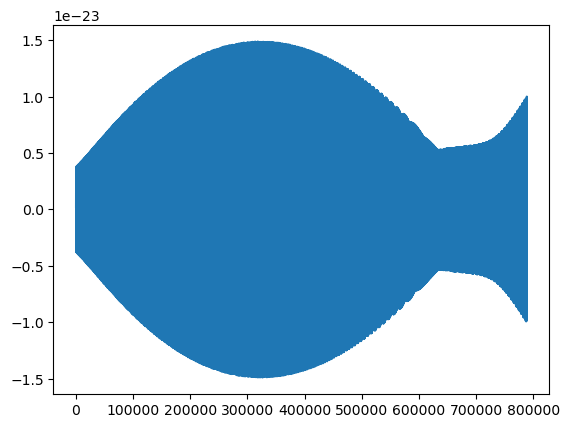

In [59]:
plt.plot(h_pt_sel1.get().real-h_datasel.get().real)
# plt.plot(h_pt1.get().imag-data.get().imag)

plt.show()

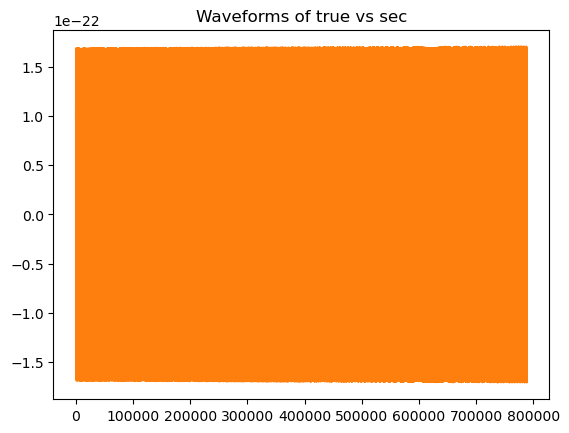

In [69]:
plt.plot(data.get().real)
plt.plot(h_pt1.get().real)
plt.title('Waveforms of true vs sec')
plt.show()

/scratch/e1498138/anaconda3/envs/fewsm/lib/python3.12/site-packages/matplotlib/cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/scratch/e1498138/anaconda3/envs/fewsm/lib/python3.12/site-packages/matplotlib/cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


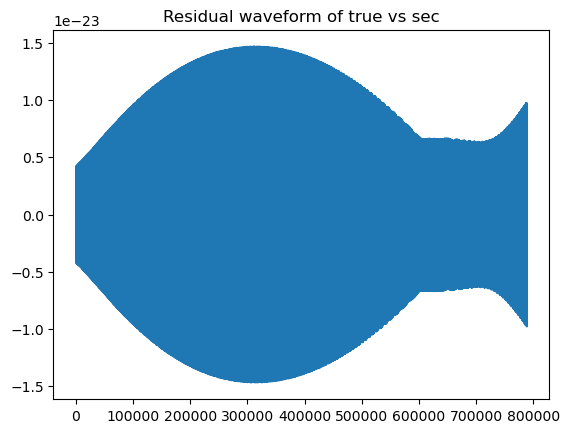

In [70]:
plt.plot(data.get().real-h_pt1.get())
plt.title('Residual waveform of true vs sec')
plt.show()

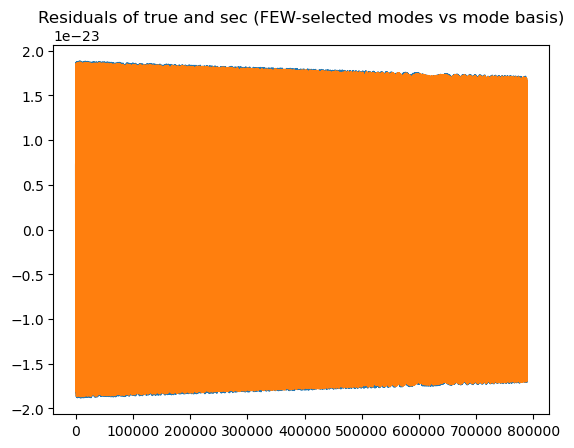

In [67]:
plt.plot(data.get().real-h_datasel.get().real)
plt.plot(h_pt1.get().real-h_pt_sel1.get().real)
plt.title('Residuals of true and sec (FEW-selected modes vs mode basis)')
plt.show()

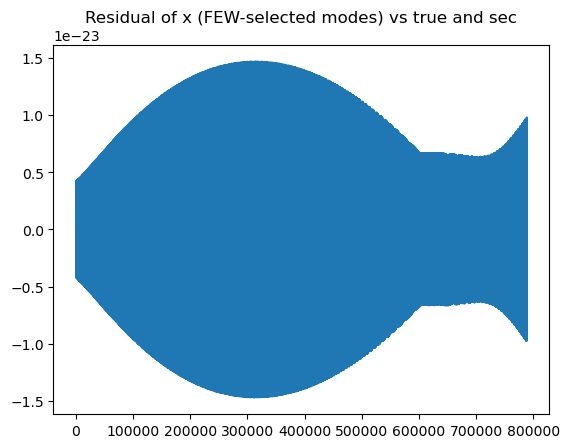

In [66]:
plt.plot(h_pt1.get().real-data.get().real)
# plt.plot(h_pt1.get().imag-data.get().imag)
plt.title('Residual of x (FEW-selected modes) vs true and sec')
plt.show()

In [62]:
gwf.rhostat(h_pt1-h_pt_sel1), gwf.rhostat(data-h_datasel)
# residual SNR of the waveform(all modes) - waveform(sel modes)
# for the true params the residual SNR above is larger than for the secondary 
# so more residual for the data? 

(array(0.77381604), array(0.79501989))

In [63]:
X_proc1_timemax = []
for template in templates_tr_proc1:
    X = gwf.Xstat_timemax(h_datasel, template)
    X_proc1_timemax.append(X.get())

In [64]:
X_proc1_timemax

[array(5.57877531),
 array(5.51871586),
 array(5.36840425),
 array(5.49477406),
 array(5.56977054),
 array(5.56999028),
 array(5.50589376),
 array(5.38876471),
 array(5.44445157),
 array(5.52989107),
 array(5.56983271),
 array(5.5711367),
 array(5.54402289),
 array(5.49253445),
 array(5.42463082),
 array(5.34617731),
 array(5.41617303),
 array(5.46695548),
 array(5.50405332),
 array(5.52914145),
 array(5.54487041),
 array(5.55407624),
 array(5.55964256),
 array(5.56281695),
 array(5.56403358),
 array(5.56379561),
 array(5.56201443),
 array(5.55823764),
 array(5.55235774),
 array(5.54161863),
 array(5.52360025),
 array(5.49533177),
 array(5.4565105),
 array(5.40075354),
 array(5.36369778),
 array(5.44077553),
 array(5.5046805),
 array(5.55170615),
 array(5.5742168),
 array(5.5642924),
 array(5.51678638),
 array(5.42379218),
 array(5.41275452),
 array(5.52061174),
 array(5.5746691),
 array(5.56401735),
 array(5.47862831),
 array(5.3919036),
 array(5.53191598),
 array(5.58193671)]

NameError: name 'chi2_proc1' is not defined

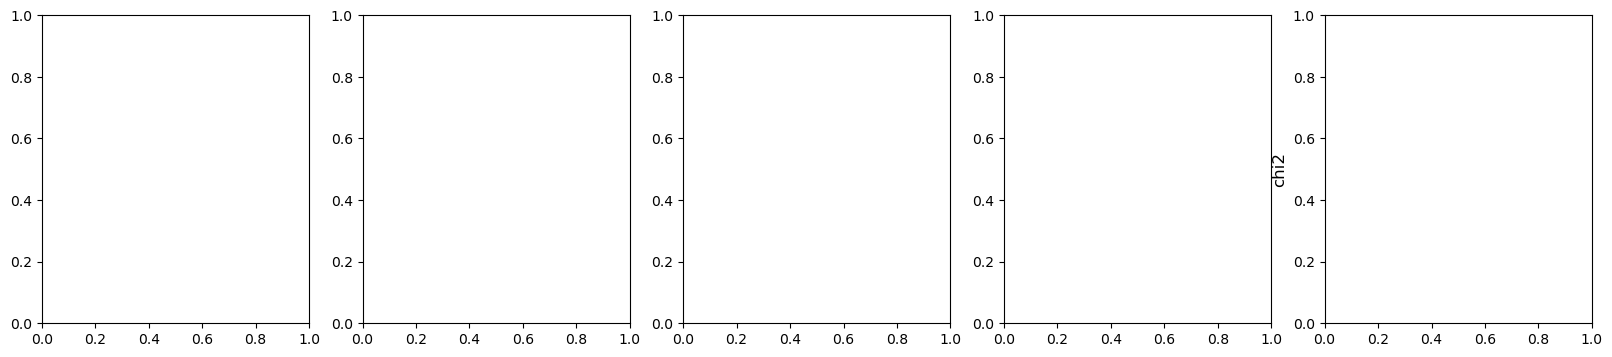

In [65]:
fig_1d, axs_1d = plt.subplots(1, 5, figsize=(20, 4))
plt.ylabel('chi2', fontsize=12)

for dim in range(5):
    ax = axs_1d[dim]

    # Plot theoretical log-density
    ax.plot(line_points_proc1[dim], chi2_proc1, '-', 
            color='blue', alpha=0.5, linewidth=2, label=r'Computed $\chi^2$')
    # ax.plot(line_points_proc2[dim], chi2_proc2, '-', 
    #         color='darkorange', alpha=0.5, linewidth=2, label='Theory Proc2')
    

    # Mark the max likelihood points
    ax.axvline(proc1_maxld_pt_1d[dim], color='blue', linestyle='--', 
               alpha=0.5, label=f'Proc1 Max Logden Point')
    # ax.axvline(proc2_maxld_pt_1d[dim], color='orange', linestyle='--', 
    #            alpha=0.5, label=f'Proc2 point')
    ax.axvline(param_true[dim], color='red', linestyle='--', 
               alpha=0.5, label='True point')
    
    ax.set_xlabel(labels[dim], fontsize=12)
    # ax.set_ylabel('opt SNR (X)', fontsize=12)
    ax.grid(True, alpha=0.3)
 
plt.legend()
plt.tight_layout()


In [ ]:
from few.utils.constants import MTSUN_SI

M_seconds = (m1) * MTSUN_SI  # total mass in seconds

# Convert geometric Omega to physical Hz
def geom_to_hz(omega, M_sec):
    return omega / (2 * np.pi * M_sec)

print(f"M_seconds: {M_seconds:.4f} s")
print(f"freq_res: {freq_res:.4e} Hz\n")

for name, wt, ws in [('Omega_phi', OmegaPhi_true, OmegaPhi_pt),
                     ('Omega_theta', OmegaTheta_true, OmegaTheta_pt),
                     ('Omega_r', OmegaR_true, OmegaR_pt)]:
    ft = geom_to_hz(wt, M_seconds)
    fs = geom_to_hz(ws, M_seconds)
    diff_hz = abs(ft - fs)
    print(f"{name:15s}  true={ft:.4e} Hz  sec={fs:.4e} Hz  |diff|={diff_hz:.4e} Hz  diff/res={diff_hz/freq_res:.2f}")
